# First model: Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. The inherent problem of this project is unsupervised, therefore we consider a range of unsupervised models, starting off with clustering.

In [231]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [232]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from data import utils

## Load Data

In [233]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])


In [234]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])


### Extracting Anomaly Data

In [235]:
# Extract extreme drought years 2018, 2019

def get_anomaly_df(df):
    df = rem_2024_2025(df)
    mask = df["Timestamp"].dt.year.isin([2018, 2019])
    return df[~mask].copy(), df[mask].copy()

def rem_2024_2025(df):
    mask = df["Timestamp"].dt.year.isin([2024, 2025])
    return df[~mask]

In [236]:
norm_ns_df, anom_ns_df = get_anomaly_df(non_spectral_df)
norm_s_df, anom_s_df = get_anomaly_df(grouped_spectral_df[["Timestamp", "NDVI_mean", "NDWI_mean", "NDRE_mean",]])

norm_eng_ns_df, anom_eng_ns_df = get_anomaly_df(eng_non_spectral_df)
norm_roll_lag_df, anom_roll_lag_df = get_anomaly_df(roll_lag_df)

### Interpolation

We present the first issue of our data using a simple merge between the non-spectral and spectral datasets.

In [237]:
master_raw_df = grouped_spectral_df.merge(non_spectral_df, on="Timestamp" ,how='right')
master_raw_df.head(7)

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation
0,2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,284.922923,301.389491,3.288490e+07,0.000000
1,2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,285.298415,295.811490,3.127135e+07,0.000000
2,2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,283.975136,296.656369,2.872766e+07,0.000000
3,2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,283.692780,298.823837,3.154392e+07,2.618651
4,2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,284.633106,302.508414,3.183471e+07,1.835338
5,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,0.290550,0.332584,0.298607,0.270337,296.744157,295.314101,293.286606,291.108126,295.740201,285.324435,304.907338,3.151798e+07,0.000000
6,2018-01-07,0.454175,0.017789,0.15485,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000


You will quickly notice that our spectral indices contain lots of `NaN` observations. This is due to the almost-weekly passes of the Sentinel-2 mission, as well as cloud-masking applied in our pre-processing steps. Luckily, NDVI follows a pretty general pattern and is not prone to extreme oscilations from one moment to the next. It is therefore not a bad idea to use the built-in **Cubic Hermit Spline** wrapper to `scipy` in `pandas` to account for these unobserved images. 

Note we also use **backfilling** to account for the missing observations at the start of our datasets, as the spectral indices are unlikely to vary much in such a short period.

In [238]:
def get_interpolated_df(spectral, timestamps):
    spectral_columns = [
        "NDVI_mean",
        "NDWI_mean",
        "NDRE_mean",
    ]

    df = spectral.merge(timestamps, on="Timestamp", how="right")
    interpolated_df = df[["Timestamp"] + spectral_columns].copy()
    interpolated_df[spectral_columns] = interpolated_df[spectral_columns].interpolate(method="pchip", limit_area="inside").bfill()

    return interpolated_df.dropna()

We create a function because we will be applying the interpolation to the anomaly dataset and the "normal"/expected dataset separately. Why? To prevent data leakage and noisy estimates. More specifically:

- There is a large chunk of observations missing around the hard split induced for the drought years 2018-2019. If we interpolate the full dataset first, ~90 days worth of observations will have _interpolated_ data points. It goes without saying that interpolation will absolutely **not** be able to reliably "estimate" 90 days of missing vegetation indices.
- Interpolating the data points around the split will carry over data from the _drought_ period to the _normal_ period. Our model will then have been exposed already to the drought conditions during its training. This is something that should rather be avoided.

We can theoretically solve this issue by building a regression model and filling large chunks (say $n>5$) of empty observations with predictions. For right now, we prioritise the unsupervised model first and therefore drop the empty observations.

In [239]:
norm_interpolated_df = get_interpolated_df(spectral=norm_s_df, timestamps=norm_ns_df["Timestamp"])
norm_interpolated_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean
0,2020-01-01,0.510191,0.162344,0.338149
1,2020-01-02,0.510191,0.162344,0.338149
2,2020-01-03,0.513993,0.168500,0.341483
3,2020-01-04,0.517872,0.174706,0.344836
4,2020-01-05,0.521828,0.180961,0.348206


In [240]:
anom_interpolated_df = get_interpolated_df(spectral=anom_s_df, timestamps=anom_ns_df["Timestamp"])
anom_interpolated_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean
0,2018-01-01,0.454175,0.15485,0.301027
1,2018-01-02,0.454175,0.15485,0.301027
2,2018-01-03,0.454175,0.15485,0.301027
3,2018-01-04,0.454175,0.15485,0.301027
4,2018-01-05,0.454175,0.15485,0.301027


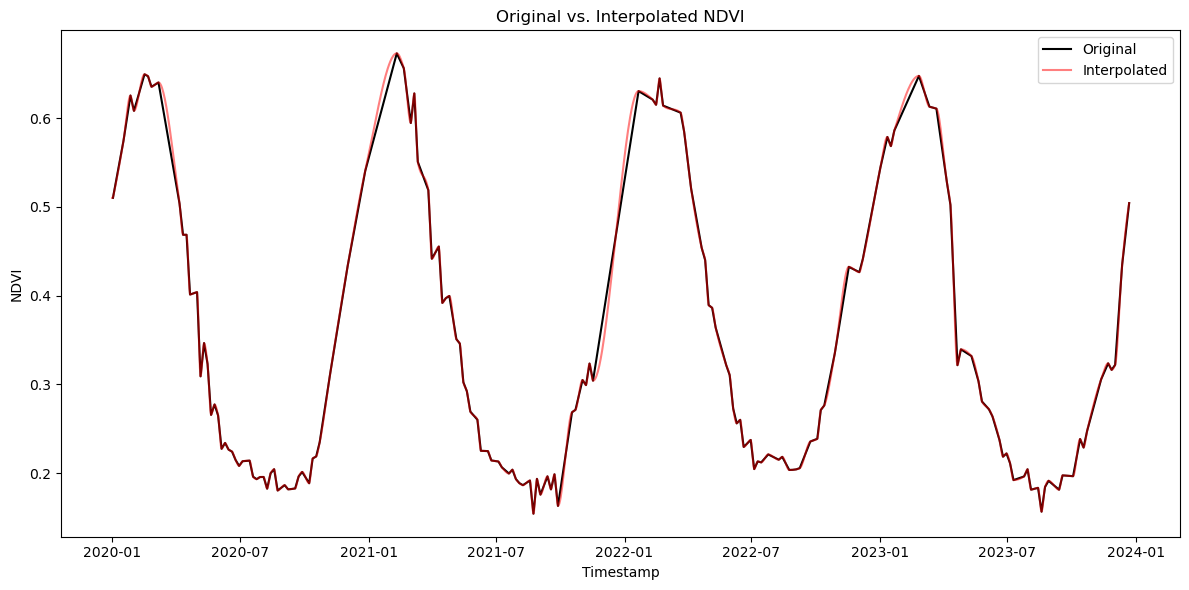

In [241]:
plot_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
plot_df, _ = get_anomaly_df(plot_df)
plt.figure(figsize=(12, 6))
plt.title("Original vs. Interpolated NDVI")
plt.plot(plot_df["Timestamp"], plot_df["NDVI_mean"], label="Original", c="black")
plt.plot(norm_interpolated_df["Timestamp"], norm_interpolated_df["NDVI_mean"], label="Interpolated", c="red", alpha=0.5)

plt.xlabel("Timestamp")
plt.ylabel("NDVI")
plt.legend()
plt.tight_layout()
plt.show()

---

## Full Model, no lagged variables or rolling statistics

As a baseline, we fit a GMM on all our engineered and remaining non-spectral variables. The log likelihood of the training sample will give us a good indication of how well the model fit to the data. Note that, since GMM's assume _continuous_ variables, we do not explicitly make use of the `in_season` or `Growth-Stage` features. We will operate under the assumption that this information is baked into `cummulative_GDD`.

In [242]:
eng_features = [
    'Timestamp',
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    'VW_PC1',  
    'Shallow_mean',
    'ST_PC1'

    # Categoricals not included
    #'Growth_Stage',
    #'in_season',
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation',
    'volumetric_soil_water_layer_3',
    'volumetric_soil_water_layer_4',
    'soil_temperature_level_4'
]


In [243]:
# Get normal data
X_part1 = norm_eng_ns_df[eng_features]
X_part2 = norm_ns_df[non_spectral_features]
X_non_spectral_norm = pd.merge(X_part2, X_part1, on="Timestamp")

# Merge with interpolated spectral dataframe
X_norm = norm_interpolated_df.merge(X_non_spectral_norm, on="Timestamp", how="left")
X_norm.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_4,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
0,2020-01-01,0.510191,0.162344,0.338149,294.218560,289.641174,300.815842,2.342209e+07,5.768824,0.286775,0.267701,292.505906,668.434571,0.323509,1.010358,294.680683,1.862650
1,2020-01-02,0.510191,0.162344,0.338149,294.688144,288.120487,302.366209,2.902789e+07,0.458307,0.286462,0.267696,292.525425,680.527919,0.318876,0.782292,295.221049,2.056825
2,2020-01-03,0.513993,0.168500,0.341483,295.368853,287.284957,302.610221,2.969595e+07,7.398956,0.286025,0.267690,292.546249,692.325508,0.311703,0.427180,295.609568,2.200804
3,2020-01-04,0.517872,0.174706,0.344836,295.601588,288.227640,302.926995,3.014462e+07,12.979295,0.285470,0.267682,292.568757,704.752826,0.304541,0.073355,295.955741,2.330165
4,2020-01-05,0.521828,0.180961,0.348206,295.907643,288.903460,302.875189,3.009218e+07,2.838473,0.284854,0.267672,292.593196,717.492150,0.299192,-0.189093,296.232326,2.435835


In [244]:
# Get anomaly data

X_part1 = anom_eng_ns_df[eng_features]
X_part2 = anom_ns_df[non_spectral_features]
X_ns_anom = pd.merge(X_part2, X_part1, on="Timestamp")

# Merge with interpolated spectral dataframe
X_anom = anom_interpolated_df.merge(X_ns_anom, on="Timestamp", how="left")
X_anom.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_4,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
0,2018-01-01,0.454175,0.15485,0.301027,293.314439,284.922923,301.389491,3.288490e+07,0.000000,0.302474,0.270380,290.955942,10.006207,0.0,0.918978,293.879077,1.550109
1,2018-01-02,0.454175,0.15485,0.301027,289.883795,285.298415,295.811490,3.127135e+07,0.000000,0.302010,0.270373,290.987094,17.411159,0.0,0.533468,293.631885,1.465590
2,2018-01-03,0.454175,0.15485,0.301027,290.475579,283.975136,296.656369,2.872766e+07,0.000000,0.301465,0.270366,291.017846,24.576912,0.0,0.244641,293.596234,1.450933
3,2018-01-04,0.454175,0.15485,0.301027,291.254956,283.692780,298.823837,3.154392e+07,2.618651,0.300741,0.270358,291.047929,32.685221,0.0,-0.025467,293.856784,1.541121
4,2018-01-05,0.454175,0.15485,0.301027,293.653434,284.633106,302.508414,3.183471e+07,1.835338,0.299777,0.270349,291.077664,43.105980,0.0,-0.281085,294.420817,1.741368


### Training

Now begins our training process. Expectations for this baseline model are not high due to there not being any consideration for correlation, lagging variables or rolling statistics. 

In [245]:
X = X_norm.drop("Timestamp", axis=1).copy()
Xa = X_anom.drop("Timestamp", axis=1).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_anom_scaled = scaler.transform(Xa)

split_i = int(len(X_scaled) * 0.7)
X_train = X_scaled[:split_i]
X_test = X_scaled[split_i:]

In [283]:

covariance_types = ['full', 'tied', 'diag', 'spherical']
components = range(1, 30)
bics = np.zeros(shape=(len(covariance_types), len(components)))

min_bic = np.inf
min_bic_k = 0
best_cov = None
best_model = None


for i, cov in enumerate(covariance_types):
    for j, k in enumerate(components):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        bics[i, j] = bic
        if bic < min_bic:
            min_bic = bic
            min_bic_k = k
            best_cov = cov
            best_model = gmm

print(f"Minimum BIC: {min_bic} with {min_bic_k} components and '{best_cov}' Covariance Matrices.")

Minimum BIC: -21981.09176885752 with 26 components and 'full' Covariance Matrices.


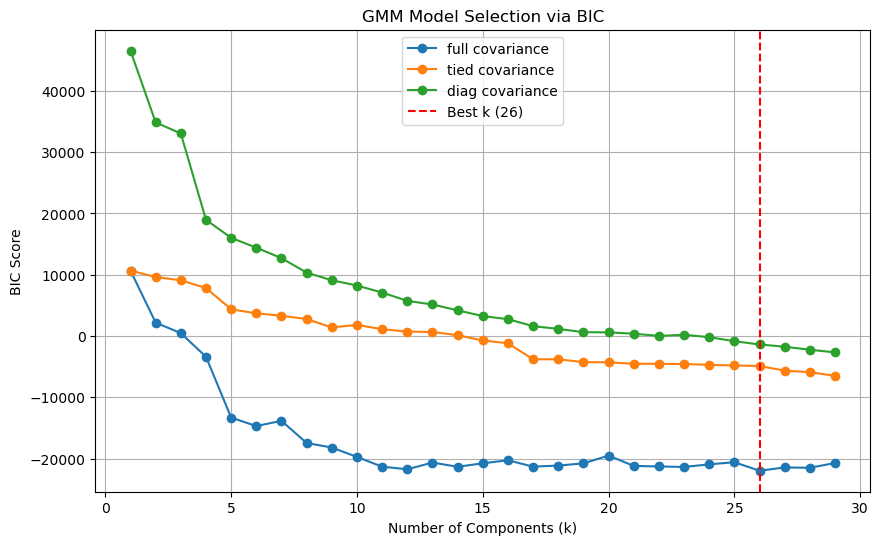

In [284]:
plt.figure(figsize=(10, 6))
for i, cov in enumerate(covariance_types):
    if cov != "spherical":
        plt.plot(components, bics[i], label=f'{cov} covariance', marker='o')

plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("GMM Model Selection via BIC")
plt.axvline(x=min_bic_k, color='red', linestyle='--', label=f'Best k ({min_bic_k})')
plt.legend()
plt.grid(True)
plt.show()

In [285]:
test_score = best_model.score(X_test)
anom_score = best_model.score(X_anom_scaled)

print(f"Test data log-likelihood: {test_score}\nAnomaly data log-likelihood: {anom_score}")

Test data log-likelihood: -2025.0226649260678
Anomaly data log-likelihood: -6037.120232230713


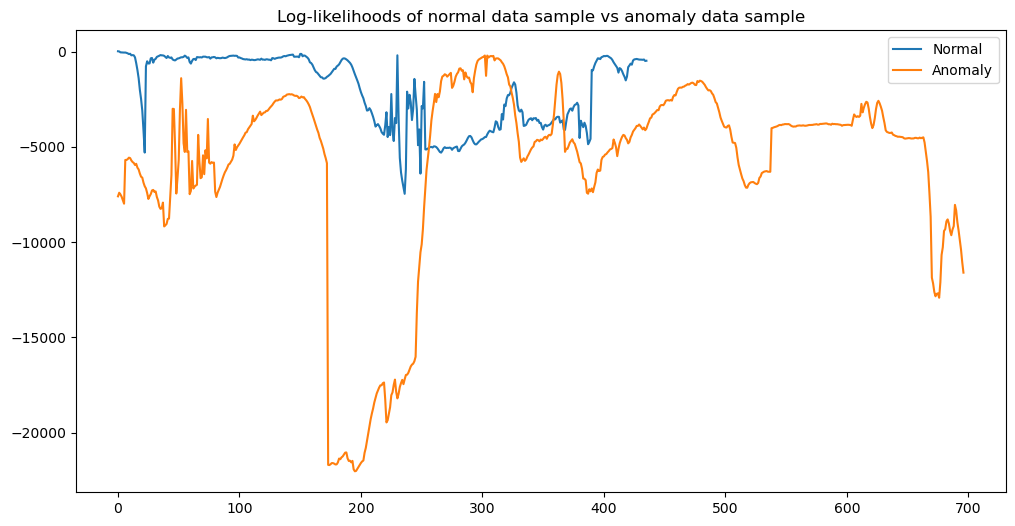

In [286]:
test_scores = best_model.score_samples(X_test)
anom_scores = best_model.score_samples(X_anom_scaled)

plt.figure(figsize=(12, 6))
plt.title("Log-likelihoods of normal data sample vs anomaly data sample")
plt.plot(test_scores, label="Normal")
plt.plot(anom_scores, label="Anomaly")
plt.legend()

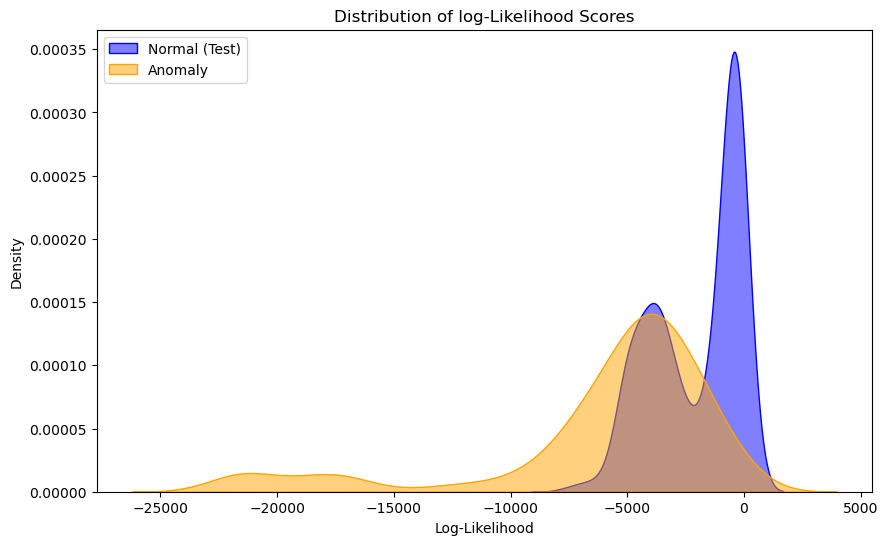

In [287]:
plt.figure(figsize=(10, 6))
sns.kdeplot(test_scores, label="Normal (Test)", fill=True, color="blue", alpha=0.5)
sns.kdeplot(anom_scores, label="Anomaly", fill=True, color="orange", alpha=0.5)

plt.title("Distribution of log-Likelihood Scores")
plt.xlabel("Log-Likelihood")
plt.ylabel("Density")
plt.legend()
plt.show()

# Rolling Data

In [252]:
roll_lag_features = [
    "Timestamp",
    
    # Temperature
    "temperature_2m_lag_7",
    "temperature_2m_lag_30",
    "temperature_2m_7D_mean",
    "temperature_2m_30D_mean",

    # Solar radiation
    "surface_solar_radiation_downwards_sum_lag_7",
    "surface_solar_radiation_downwards_sum_lag_30",
    "surface_solar_radiation_downwards_sum_7D_sum",
    "surface_solar_radiation_downwards_sum_30D_sum",

    # Precipitation
    "precipitation_lag_7",
    "precipitation_lag_30",
    "precipitation_7D_sum",
    "precipitation_30D_sum",

    # Root-zone soil moisture
    "root_weighted_soil_moisture_lag_7",
    "root_weighted_soil_moisture_lag_30",
    "root_weighted_soil_moisture_7D_mean",
    "root_weighted_soil_moisture_30D_mean",

    # Vegetation indices (PCA components)
    "VW_PC1_lag_7",
    "VW_PC1_lag_30",
    "VW_PC1_7D_mean",
    "VW_PC1_30D_mean",

    # Surface temperature PCA
    "ST_PC1_lag_7",
    "ST_PC1_lag_30",
    "ST_PC1_7D_mean",
    "ST_PC1_30D_mean",

    # Shallow soil moisture
    "Shallow_mean_lag_7",
    "Shallow_mean_lag_30",
    "Shallow_mean_7D_mean",
    "Shallow_mean_30D_mean",

    # Deep volumetric Soil Water Layers
    "volumetric_soil_water_layer_3_7D_mean",
    "volumetric_soil_water_layer_3_30D_mean",
    "volumetric_soil_water_layer_4_7D_mean",
    "volumetric_soil_water_layer_4_30D_mean",
    
    'volumetric_soil_water_layer_3_lag_7',
    'volumetric_soil_water_layer_3_lag_30',
    'volumetric_soil_water_layer_4_lag_7',
    'volumetric_soil_water_layer_4_lag_30',

    # Deep soil temperature layer
    "soil_temperature_level_4_7D_mean",
    "soil_temperature_level_4_30D_mean",
    'soil_temperature_level_4_lag_7',
    'soil_temperature_level_4_lag_30'

]

eng_features = [
    'Timestamp',
    'in_season', 
    'cumulative_GDD', 
    'Growth_Stage',
    'root_weighted_soil_moisture', 
    'VW_PC1', 
    'VW_PC2', 
    'Shallow_mean',
    'ST_PC1'
]
